# Multimodal Topic Mining for Pokemon Trading Cards

## What We're Trying to Do

So here's the idea: can we use BERTopic with CLIP embeddings to discover meaningful patterns in Pokemon cards just by looking at the images and some basic info, without explicitly telling the model what type each Pokemon is? And more importantly, what happens when we accidentally (or deliberately) leak information like Pokemon names into our data?

### The Questions We Want to Answer

**Can we actually find topics without using Pokemon names?**  
This is the interesting part. If we only use visual features and metadata (HP, evolution stage, etc.), can we still cluster Pokemon cards into coherent groups? Or do we need those explicit labels?

**How much does data leakage mess up our results?**  
Data leakage is everywhere in real datasets. When Pokemon names sneak into the captions, how much does that artificially boost our performance? And what does that tell us about whether the model is actually learning anything useful?

**Which matters more - text or images?**  
We have both card images and text captions. Do they contribute equally? Does the answer change when we include Pokemon names in the captions?

### How We Set This Up

We're running two experiments to see what data leakage actually does:

**Scenario A (The Realistic One):** Generic visual descriptions only - stuff like "warm color palette" or "cool blue tones" for topic discovery. Then we test classification using just metadata-only captions. This is what you'd have in the real world when you don't know the Pokemon identities ahead of time.

**Scenario B (The Leaky One):** Pokemon names everywhere - in both topic discovery and classification. This is what happens when identifying information leaks into your training data (which happens more often than you'd think).

The point here is simple: by comparing these two scenarios, we can actually measure how much of the model's performance is real learning versus just memorizing which name maps to which type.

---

## The Dataset

**Pokemon Trading Cards**
- **Source:** Pokemon TCG API via Kaggle
- **Size:** 5,119 cards with images and full metadata
- **What's in it:** 
  - Card artwork images (the actual visual part)
  - Game stats: HP, evolution stages, number of attacks, retreat costs, weaknesses/resistances
  - Generation info, rarity levels
  - Pokemon names (which we'll use strategically to study data leakage)

**Why Pokemon cards?**

Honestly, Pokemon cards are perfect for this because:
- The artwork has really distinctive visual patterns that correlate with types (Fire types have warm colors, Water types have blues, etc.)
- There's structured metadata that means something in the game
- We have clear ground truth (the actual Pokemon types) to validate our discovered topics
- We can control exactly when to include or exclude Pokemon names, which makes studying data leakage straightforward

In [ ]:
# # Core data manipulation and numerical computing
# !pip install -q pandas numpy

# # Image processing and HTTP requests
# !pip install -q Pillow requests

# # Progress bars
# !pip install -q tqdm

# # Multimodal embeddings with CLIP
# !pip install -q sentence-transformers

# # Topic mining and clustering
# !pip install -q bertopic umap-learn hdbscan

# # Machine learning
# !pip install -q scikit-learn

# # Visualization
# !pip install -q matplotlib seaborn

## Setup: Install Required Libraries

This notebook is designed to run on **Google Colab**. The cell below will install all necessary libraries. This may take a few minutes on first run.

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import requests
import subprocess
import zipfile
from io import BytesIO
from tqdm import tqdm
from PIL import Image
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Download (Optional)

**Note:** If running on Google Colab, you have two options:
1. Upload the pre-processed dataset (`pokemon_cards_metadata.csv` + images folder) to your Colab session
2. Use the function below to download from Kaggle (requires Kaggle API credentials)

In [234]:
def download_and_process_pokemon_cards(save_dir='pokemon_cards', num_cards=1000):
    """
    Download Pokemon TCG dataset from Kaggle and download card images.
    Everything is saved in a single directory.
    
    Args:
        save_dir: Directory to save everything (images and metadata)
        num_cards: Number of cards to process
        
    Returns:
        df_final: Processed dataframe with image paths
    """
    
    # Create directory structure
    os.makedirs(f"{save_dir}/images", exist_ok=True)
    temp_dir = f"{save_dir}/temp"
    os.makedirs(temp_dir, exist_ok=True)
    
    # Step 1: Download dataset from Kaggle
    print("Downloading Pokemon TCG dataset from Kaggle...")
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'adampq/pokemon-tcg-all-cards-1999-2023', '-p', temp_dir],
        capture_output=True,
        text=True
    )
    
    # Step 2: Extract the dataset
    zip_path = f'{temp_dir}/pokemon-tcg-all-cards-1999-2023.zip'
    if os.path.exists(zip_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)
    
    # Step 3: Load the CSV
    csv_files = [f for f in os.listdir(temp_dir) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError("No CSV files found in dataset directory")
    
    cards_file = f'{temp_dir}/{csv_files[0]}'
    df_raw = pd.read_csv(cards_file)
    print(f"Loaded {len(df_raw)} total cards from Kaggle dataset\n")
    
    # Step 4: Download images for subset
    df = df_raw.head(num_cards).copy()
    print(f"Processing {len(df)} cards...")
    
    successful = []
    failed = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Downloading images"):
        try:
            card_id = row['id']
            set_code, number = card_id.split('-')
            
            downloaded = False
            for url_template in [
                f"https://images.pokemontcg.io/{set_code}/{number}_hires.png",
                f"https://images.pokemontcg.io/{set_code}/{number}.png"
            ]:
                try:
                    response = requests.get(url_template, timeout=10)
                    response.raise_for_status()
                    
                    img = Image.open(BytesIO(response.content)).convert('RGB')
                    img_path = f"{save_dir}/images/card_{idx:05d}.jpg"
                    img.save(img_path, 'JPEG', quality=95)
                    
                    df.at[idx, 'image_path'] = img_path
                    successful.append(idx)
                    downloaded = True
                    break
                except:
                    continue
            
            if not downloaded:
                failed.append(card_id)
                
        except Exception as e:
            failed.append(row.get('id', f'idx_{idx}'))
            continue
    
    # Step 5: Save only the final processed dataset
    df_final = df.loc[successful].copy()
    csv_path = f'{save_dir}/pokemon_cards_metadata.csv'
    df_final.to_csv(csv_path, index=False)
    
    # Step 6: Clean up temporary files
    print("\nCleaning up temporary files...")
    import shutil
    shutil.rmtree(temp_dir)
    
    print(f"Successfully processed: {len(df_final)} cards")
    print(f"Failed to download: {len(failed)} cards")
    print(f"Images saved to: {save_dir}/images/")
    print(f"Metadata saved to: {csv_path}")
    
    return df_final

In [ ]:
save_dir = 'pokemon_cards'
df = download_and_process_pokemon_cards(save_dir=save_dir, num_cards=6000)
print(f"Downloaded {len(df)} cards to {save_dir}")

## 1. Load Data

In [236]:
# Load Pokemon cards data
cards_df = pd.read_csv('./pokemon_cards/pokemon_cards_metadata.csv')

# Parse lists
import ast
def safe_parse(val):
    if pd.isna(val): return []
    try: return ast.literal_eval(val) if isinstance(val, str) else val
    except: return []

cards_df['types'] = cards_df['types'].apply(safe_parse)
cards_df['subtypes'] = cards_df['subtypes'].apply(safe_parse)

# Extract features
cards_df['primary_type'] = cards_df['types'].apply(lambda x: x[0] if len(x) > 0 else None)
cards_df['primary_subtype'] = cards_df['subtypes'].apply(lambda x: x[0] if len(x) > 0 else None)
cards_df['hp_numeric'] = pd.to_numeric(cards_df['hp'], errors='coerce')
cards_df['num_attacks'] = cards_df['attacks'].apply(lambda x: len(safe_parse(x)))
cards_df['retreat_cost_count'] = cards_df['retreatCost'].apply(lambda x: len(safe_parse(x)))
cards_df['has_weakness'] = cards_df['weaknesses'].notna()
cards_df['has_resistance'] = cards_df['resistances'].notna()

# Filter to Pokemon cards only
pokemon_only = cards_df[
    cards_df['primary_type'].notna() &
    cards_df['hp_numeric'].notna()
].copy()

print(f"Loaded {len(pokemon_only)} Pokemon cards")

Loaded 5119 Pokemon cards


## 2. Caption Engineering Strategy

Here's where things get interesting. How we write captions completely changes what the model can learn. We need different caption styles for different parts of our experiment.

### The Three Caption Types

#### 1. `caption_clean` - Just the Facts
This one contains only game mechanics, zero identifying information:
- Evolution stage (Basic, Stage 1, Stage 2)
- Exact HP values
- Where it sits in the evolution chain (basic form, final form, middle stage)
- Number of attacks
- Retreat cost
- Whether it has weaknesses or resistances
- Which Pokemon generation (Gen 1 through Gen 8)
- Card rarity

**When we use this:** For testing classification in Scenario A. This shows how hard the problem actually is when you only have metadata.

**Example:** *"Stage 2 evolution. HP 80. final evolution form. single attack move. retreat cost 3. has weakness. First generation. Rare Holo"*

#### 2. `caption_visual_hints` - Generic Visual Clues
Same metadata as above, plus vague color descriptions:
- Stuff like "warm color palette", "cool blue tones", "natural green themes"
- Still metadata-heavy
- Intentionally vague so we don't give away the Pokemon type

**When we use this:** For topic discovery in Scenario A. The color hints help BERTopic find clusters that actually correspond to types, without us explicitly saying "this is Fire type" or "this is Water type."

**Why this approach?** In real scenarios, you might have generic descriptions like "predominantly red tones" or "nature-themed imagery" without knowing the specific entity. We're testing if that's enough.

**Example:** *"mystical purple tones. Stage 2 evolution stage. evolved form. medium HP 80. 1 attack moves. high retreat cost. has type weakness. Gen 1 classic. Rare Holo"*

#### 3. `caption_with_names` - Everything Including the Kitchen Sink
Pokemon names right in the caption:
- Literally just "Pokemon [Name]" plus basic metadata
- Simplified compared to the others

**When we use this:** Both topic discovery and classification in Scenario B. This is our data leakage experiment.

**Why intentionally leak data?** Because we need to measure exactly how much difference it makes. Lots of real datasets have this problem hiding in them, and people don't realize how much it's inflating their accuracy numbers.

**Example:** *"Pokemon Alakazam. Stage 2 evolution. HP 80. First"*

### The Key Trick: Using Different Captions for Different Steps

This is crucial - we're not using the same captions everywhere:
- **Scenario A Topic Discovery:** `caption_visual_hints` (helps clustering)
- **Scenario A Classification Testing:** `caption_clean` (shows true difficulty)
- **Scenario B (both steps):** `caption_with_names` (demonstrates leakage effect)

By keeping these separate in Scenario A, we can fairly compare realistic performance against the inflated performance you get from data leakage.

In [248]:
def create_caption_clean(row):
    """Metadata only - NO visual hints, NO names"""
    parts = []
    
    # Evolution stage
    if pd.notna(row['primary_subtype']): 
        parts.append(f"{row['primary_subtype']} evolution")
    
    # Specific HP value
    if pd.notna(row['hp_numeric']):
        parts.append(f"HP {int(row['hp_numeric'])}")
    
    # Evolution path details
    if pd.notna(row['evolvesFrom']) and pd.notna(row['evolvesTo']): 
        parts.append("middle evolution stage")
    elif pd.notna(row['evolvesFrom']): 
        parts.append("final evolution form")
    elif pd.notna(row['evolvesTo']): 
        parts.append("basic Pokemon with evolution")
    else: 
        parts.append("non-evolving Pokemon")
    
    # Attack details
    if row['num_attacks'] >= 2: 
        parts.append(f"{row['num_attacks']} attack moves")
    elif row['num_attacks'] == 1: 
        parts.append("single attack move")
    else:
        parts.append("no attacks")
    
    # Retreat cost specifics
    if row['retreat_cost_count'] >= 3: 
        parts.append(f"retreat cost {row['retreat_cost_count']}")
    elif row['retreat_cost_count'] > 0: 
        parts.append(f"retreat cost {row['retreat_cost_count']}")
    else: 
        parts.append("free retreat")
    
    # Weakness and resistance
    if row['has_weakness'] and row['has_resistance']:
        parts.append("has weakness and resistance")
    elif row['has_weakness']:
        parts.append("has weakness")
    elif row['has_resistance']:
        parts.append("has resistance")
    
    # Generation
    if pd.notna(row['generation']): 
        parts.append(f"{row['generation']} generation")
    
    # Rarity
    if pd.notna(row['rarity']): 
        parts.append(row['rarity'])
    
    return ". ".join(parts)


def create_caption_with_names(row):
    """Same metadata + Pokemon name (data leakage)"""
    parts = []
    if pd.notna(row['name']): parts.append(f"Pokemon {row['name']}")
    if pd.notna(row['primary_subtype']): parts.append(f"{row['primary_subtype']} evolution")
    if pd.notna(row['hp_numeric']): parts.append(f"HP {int(row['hp_numeric'])}")
    if pd.notna(row['generation']): parts.append(row['generation'])
    return ". ".join(parts)


def create_caption_visual_hints(row):
    """Mild visual hints for topic discovery (warm colors, blue tones, etc.)"""
    parts = []

    # Visual themes - generic colors
    visual_themes = {
        'Fire': 'warm color palette',
        'Water': 'cool blue tones',
        'Grass': 'natural green themes',
        'Lightning': 'bright yellow energy',
        'Psychic': 'mystical purple tones',
        'Fighting': 'earth tone colors',
        'Colorless': 'neutral color scheme',
        'Darkness': 'dark shadowy appearance',
        'Metal': 'metallic silver appearance',
        'Dragon': 'dramatic multi-colored design',
        'Fairy': 'soft pink coloring'
    }

    if pd.notna(row['primary_type']) and row['primary_type'] in visual_themes:
        parts.append(visual_themes[row['primary_type']])

    # Metadata (same structure as caption_clean)
    if pd.notna(row['primary_subtype']):
        parts.append(f"{row['primary_subtype']} evolution stage")

    if pd.notna(row['evolvesFrom']):
        parts.append("evolved form")
    elif pd.notna(row['evolvesTo']):
        parts.append("basic form with evolution")
    else:
        parts.append("no evolution")

    if pd.notna(row['hp_numeric']):
        hp_val = int(row['hp_numeric'])
        if hp_val >= 100:
            parts.append(f"high HP {hp_val}")
        elif hp_val >= 70:
            parts.append(f"medium HP {hp_val}")
        else:
            parts.append(f"low HP {hp_val}")

    if row['num_attacks'] > 0:
        parts.append(f"{row['num_attacks']} attack moves")

    if row['retreat_cost_count'] >= 3:
        parts.append("high retreat cost")
    elif row['retreat_cost_count'] > 0:
        parts.append(f"retreat cost {row['retreat_cost_count']}")
    else:
        parts.append("no retreat cost")

    if row['has_weakness']:
        parts.append("has type weakness")
    if row['has_resistance']:
        parts.append("has type resistance")

    if pd.notna(row['generation']):
        gen_map = {
            'First': 'Gen 1 classic', 'Second': 'Gen 2', 'Third': 'Gen 3',
            'Fourth': 'Gen 4', 'Fifth': 'Gen 5', 'Sixth': 'Gen 6',
            'Seventh': 'Gen 7', 'Eighth': 'Gen 8'
        }
        parts.append(gen_map.get(row['generation'], row['generation']))

    if pd.notna(row['rarity']):
        parts.append(row['rarity'])

    return ". ".join(parts) if parts else "Pokemon card"


# Generate all three caption variants
pokemon_only['caption_clean'] = pokemon_only.apply(create_caption_clean, axis=1)
pokemon_only['caption_with_names'] = pokemon_only.apply(create_caption_with_names, axis=1)
pokemon_only['caption_visual_hints'] = pokemon_only.apply(create_caption_visual_hints, axis=1)

print("✓ Generated all caption variants")
print(f"\nExample captions for first card:")
print(f"  Clean:      {pokemon_only.iloc[0]['caption_clean']}")
print(f"  Visual Hints: {pokemon_only.iloc[0]['caption_visual_hints']}")
print(f"  With Names: {pokemon_only.iloc[0]['caption_with_names']}")

✓ Generated all caption variants

Example captions for first card:
  Clean:      Stage 2 evolution. HP 80. final evolution form. single attack move. retreat cost 3. has weakness. First generation. Rare Holo
  Visual Hints: mystical purple tones. Stage 2 evolution stage. evolved form. medium HP 80. 1 attack moves. high retreat cost. has type weakness. Gen 1 classic. Rare Holo
  With Names: Pokemon Alakazam. Stage 2 evolution. HP 80. First


## 3. Function 1: topic_miner()

**What it does:** Discovers multimodal topics using BERTopic with CLIP embeddings.

### How the Pipeline Works

We're combining a few different techniques here:

**1. CLIP Embeddings for Multimodal Learning**
- Using the `clip-ViT-B-32` model to encode both text captions and card images
- CLIP is pretrained to understand the relationship between images and text in the same embedding space
- Text gets encoded → 512 dimensions
- Images get encoded → 512 dimensions  
- We concatenate them → 1024 dimensions of multimodal goodness

**2. UMAP for Dimensionality Reduction**
- Takes those 1024 dimensions down to 10
- Configured with 15 neighbors, cosine distance
- Keeps the local structure intact while making clustering actually feasible

**3. HDBSCAN for Clustering**
- Minimum cluster size: 50 cards (so we get meaningful topics, not tiny fragments)
- Minimum samples: 10 (makes clusters more robust)
- Works in the UMAP-reduced space
- Figures out the number of clusters automatically
- Labels outliers as topic -1

**4. BERTopic for Making Sense of It All**
- Extracts representative words from the captions using CountVectorizer
- Gives us human-readable topic labels
- Makes visualization and interpretation actually possible

### Why These Choices?

**CLIP over separate encoders:** CLIP learns a shared representation space for text and images during pretraining. This means it naturally aligns visual and textual concepts, which is exactly what we need for finding topics that span both modalities.

**HDBSCAN over K-Means:** With K-Means you need to decide how many clusters to make beforehand. HDBSCAN figures this out on its own, handles clusters of different sizes (not all Pokemon types are equally common), and can flag outliers instead of forcing everything into a cluster.

**Concatenating instead of averaging:** We concatenate the text and image embeddings rather than averaging them because we want to preserve all the information from both sides. The classifier will learn which parts to pay attention to.

### What Goes In and What Comes Out

**Parameters:**
- `df`: Your DataFrame with card data and image paths
- `caption_col`: Which caption variant to use (visual_hints, clean, or with_names)
- `name`: A description for logging purposes

**Returns:**
- `df_result`: Same DataFrame but now with a `topic_id` column
- `topic_model`: The trained BERTopic model (for viz and analysis)
- `embeddings`: Those 1024-dimensional multimodal embeddings (needed later for predict)

In [238]:
def topic_miner(df, caption_col, name=""):
    """Mine topics using BERTopic + CLIP"""
    print(f"\n{'='*80}")
    print(f"TOPIC MINING: {name}")
    print(f"{'='*80}")

    model = SentenceTransformer('clip-ViT-B-32')

    print("Encoding text...")
    text_embeddings = model.encode(df[caption_col].tolist(), show_progress_bar=True, batch_size=64)

    print("Encoding images...")
    images = [Image.open(path).convert('RGB') for path in df['image_path']]
    image_embeddings = model.encode(images, show_progress_bar=True, batch_size=32)

    embeddings = np.concatenate([text_embeddings, image_embeddings], axis=1)

    umap_model = UMAP(n_neighbors=15, n_components=10, metric='cosine', random_state=42)
    hdbscan_model = HDBSCAN(min_cluster_size=50, min_samples=10, metric='euclidean',
                             cluster_selection_epsilon=0.0, prediction_data=True)
    vectorizer = CountVectorizer(stop_words='english', max_features=1000)

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        verbose=False
    )

    print("Fitting BERTopic...")
    topics, probs = topic_model.fit_transform(df[caption_col].tolist(), embeddings)

    df_result = df.copy()
    df_result['topic_id'] = topics

    # FIX: Convert to numpy array
    topics_array = np.array(topics)
    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    outlier_rate = (topics_array == -1).sum() / len(topics_array)

    print(f"\nTopics discovered: {n_topics}")
    print(f"Outlier rate: {outlier_rate:.1%}")

    df_valid = df_result[df_result['topic_id'] != -1]
    print("\nTopic purity:")
    for topic_id in sorted(df_valid['topic_id'].unique())[:10]:
        topic_cards = df_valid[df_valid['topic_id'] == topic_id]
        dominant_type = topic_cards['primary_type'].mode()[0]
        purity = (topic_cards['primary_type'] == dominant_type).mean()
        print(f"  Topic {topic_id}: {len(topic_cards)} cards | {dominant_type:10s} | {purity:.1%}")

    print(f"{'='*80}\n")

    return df_result, topic_model, embeddings

## 4. Scenario A - The Realistic Approach

### What We're Testing

Can we discover meaningful topics using only:
- Generic visual descriptions (like "warm palette" or "cool blue tones")
- The actual card images
- Game metadata (HP, evolution, attacks, etc.)

**Without** Pokemon names or explicit type labels?

### The Game Plan

We use `caption_visual_hints` for topic discovery. These captions have generic color descriptions that happen to correlate with Pokemon types (Fire types tend toward warm colors, Water types toward cool blues) but they never explicitly state the type or Pokemon name.

### What We Expect to See

If this works, we should get:
- Something like 8-12 topics that roughly map to Pokemon types
- High topic purity (most cards in a topic should share the same actual type)
- Evidence that visual features + subtle hints are enough for topic discovery

### What This Actually Tells Us

Basically, we're testing whether **indirect visual cues** combined with **actual card artwork** can reveal the hidden structure (Pokemon types) without us explicitly labeling anything. This is similar to real-world scenarios where you might describe products by color or style without knowing the exact categories upfront.

In [239]:
df_visual, model_visual, embeddings_visual = topic_miner(
    pokemon_only,
    'caption_visual_hints',
    name="Scenario A: Visual Hints (Realistic)"
)


TOPIC MINING: Scenario A: Visual Hints (Realistic)
Encoding text...


Batches: 100%|██████████| 80/80 [00:19<00:00,  4.11it/s]


Encoding images...


Batches: 100%|██████████| 160/160 [03:14<00:00,  1.22s/it]


Fitting BERTopic...

Topics discovered: 9
Outlier rate: 0.0%

Topic purity:
  Topic 0: 849 cards | Grass      | 100.0%
  Topic 1: 823 cards | Water      | 98.9%
  Topic 2: 803 cards | Colorless  | 98.9%
  Topic 3: 690 cards | Psychic    | 100.0%
  Topic 4: 577 cards | Fighting   | 100.0%
  Topic 5: 486 cards | Fire       | 100.0%
  Topic 6: 474 cards | Lightning  | 100.0%
  Topic 7: 216 cards | Darkness   | 100.0%
  Topic 8: 201 cards | Metal      | 100.0%



In [240]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

def visualize_topic_with_cards(df, topic_id, n_samples=6, figsize=(18, 6)):
    """Show sample Pokemon cards for a topic with statistics"""
    topic_cards = df[df['topic_id'] == topic_id]

    if len(topic_cards) == 0:
        print(f"Topic {topic_id} has no cards!")
        return

    # Statistics
    dominant_type = topic_cards['primary_type'].mode()[0]
    type_counts = topic_cards['primary_type'].value_counts()
    purity = (type_counts.iloc[0] / len(topic_cards) * 100)
    avg_hp = topic_cards['hp_numeric'].mean()

    # Sample cards
    sample_cards = topic_cards.sample(min(n_samples, len(topic_cards)), random_state=42)

    # Plot
    fig, axes = plt.subplots(2, n_samples, figsize=figsize,
                              gridspec_kw={'height_ratios': [4, 1]})

    title = f"Topic {topic_id}: {len(topic_cards)} cards | {dominant_type} ({purity:.0f}% pure) | Avg HP: {avg_hp:.0f}"
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Show cards
    for idx, (_, card) in enumerate(sample_cards.iterrows()):
        ax = axes[0, idx] if n_samples > 1 else axes[0]
        try:
            img = Image.open(card['image_path'])
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(card['name'][:15], fontsize=8)
        except:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')

    # Type distribution bar
    ax_dist = plt.subplot(2, 1, 2)
    type_colors = {
        'Fire': '#FF4422', 'Water': '#3399FF', 'Grass': '#77CC55',
        'Lightning': '#FFCC33', 'Psychic': '#AA66CC', 'Fighting': '#BB7744',
        'Colorless': '#AAAAAA', 'Darkness': '#554466', 'Metal': '#AAAABB',
        'Dragon': '#7766EE', 'Fairy': '#FFAAEE'
    }
    colors = [type_colors.get(t, '#CCC') for t in type_counts.index]
    ax_dist.barh(range(len(type_counts)), type_counts.values, color=colors)
    ax_dist.set_yticks(range(len(type_counts)))
    ax_dist.set_yticklabels(type_counts.index)
    ax_dist.set_xlabel('Count')
    ax_dist.set_title('Type Distribution')
    ax_dist.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


DISCOVERED TOPICS - SAMPLE CARDS


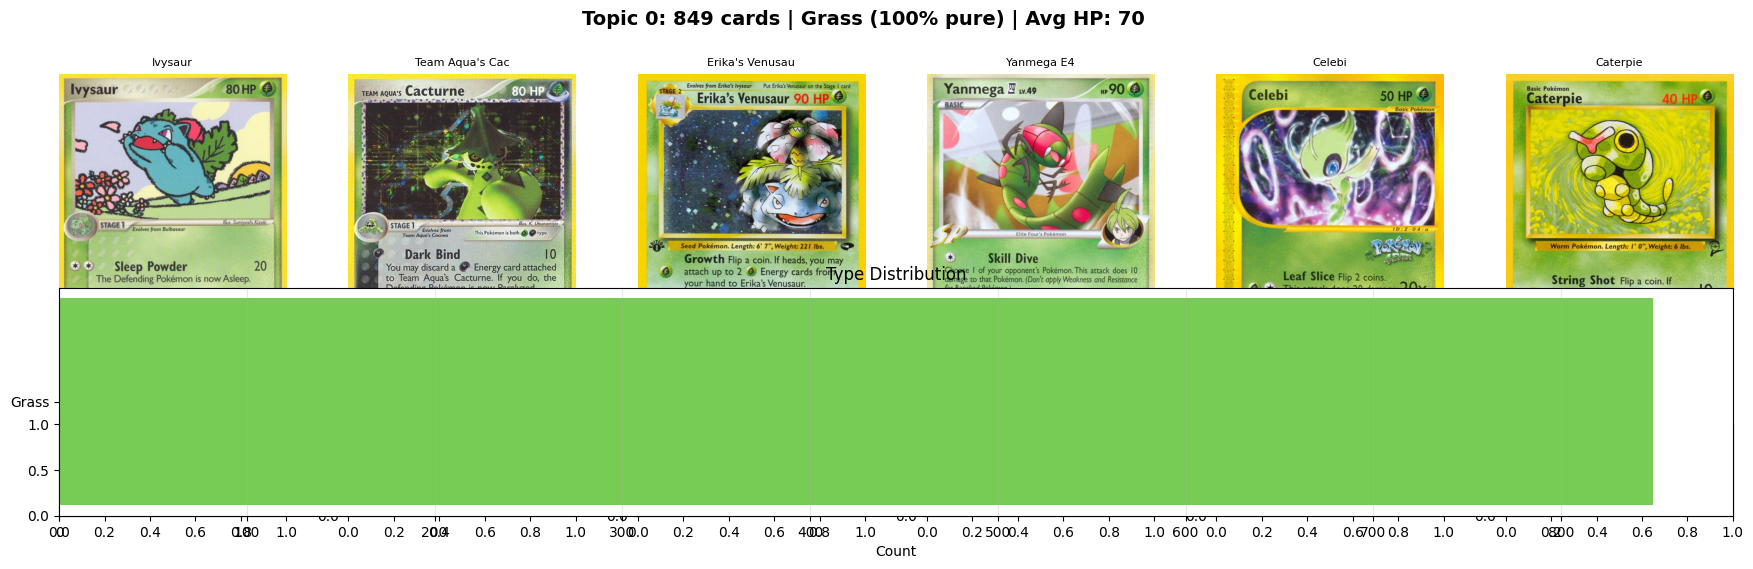

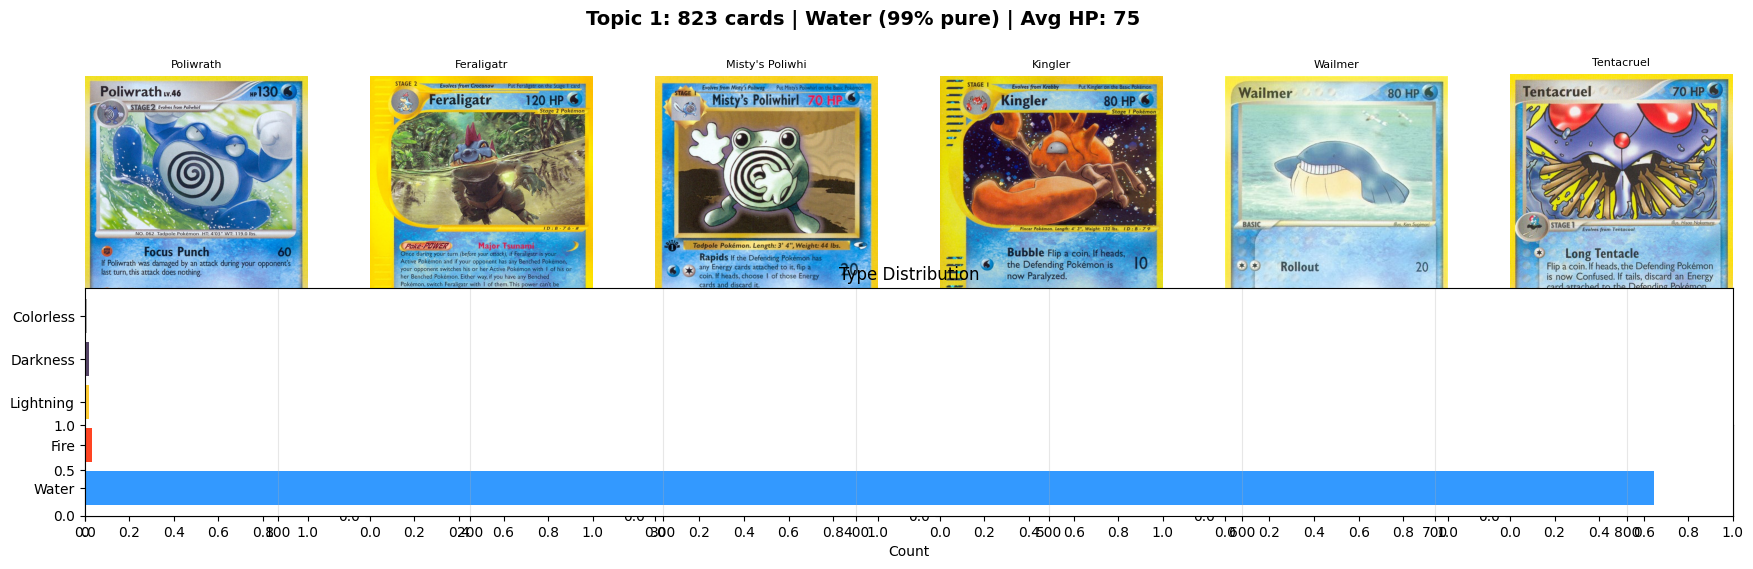

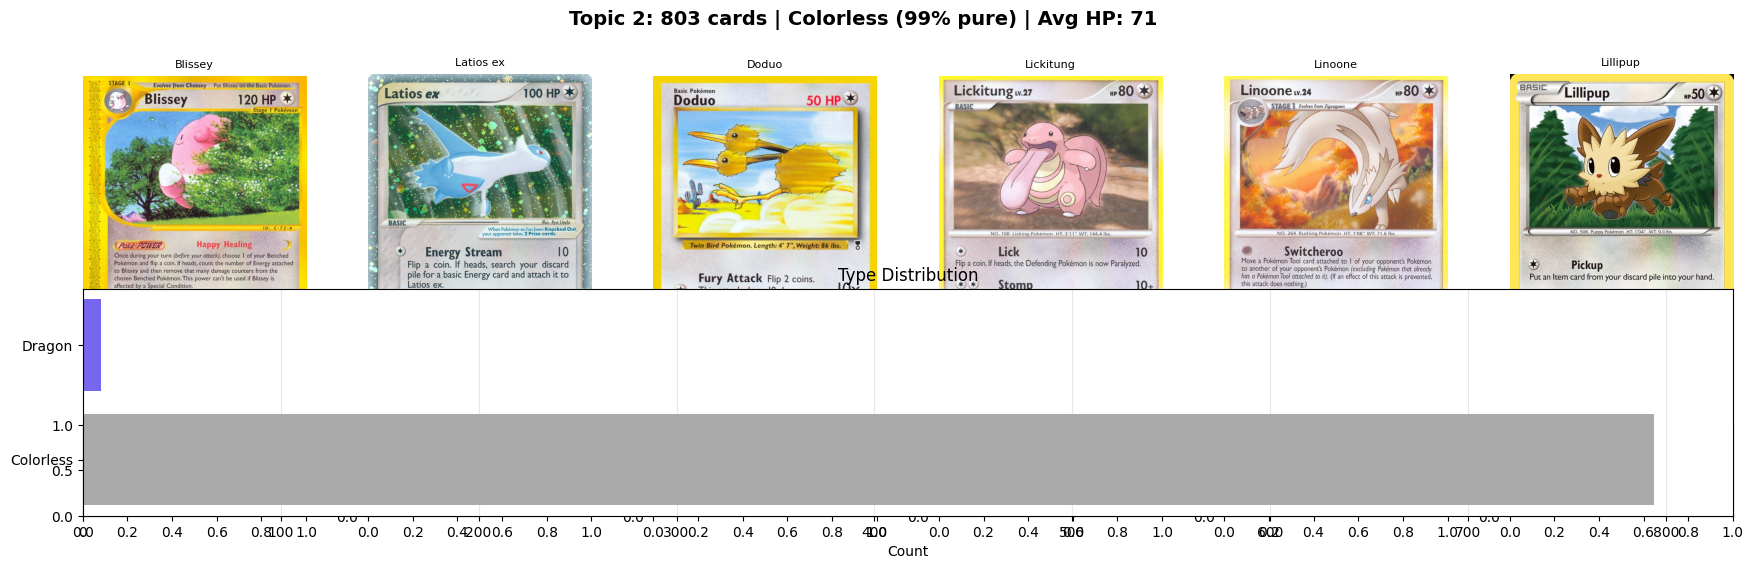

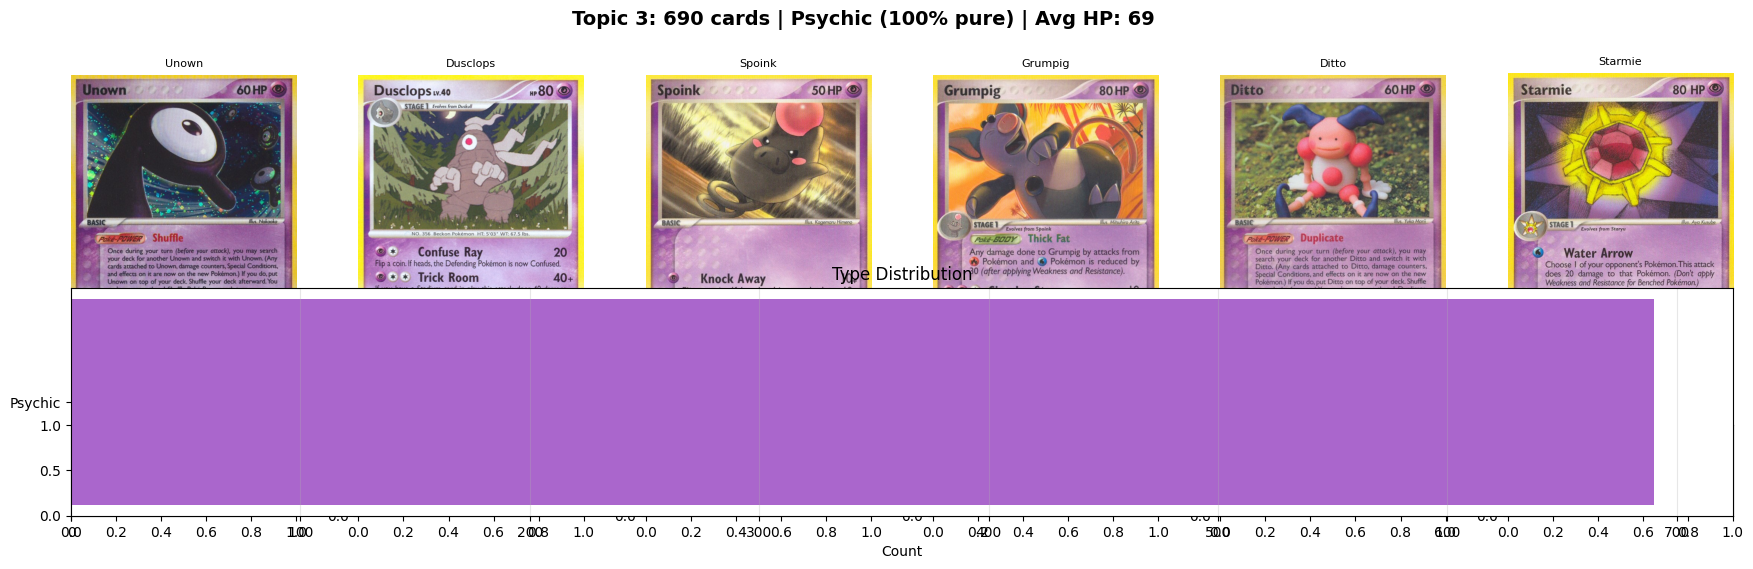

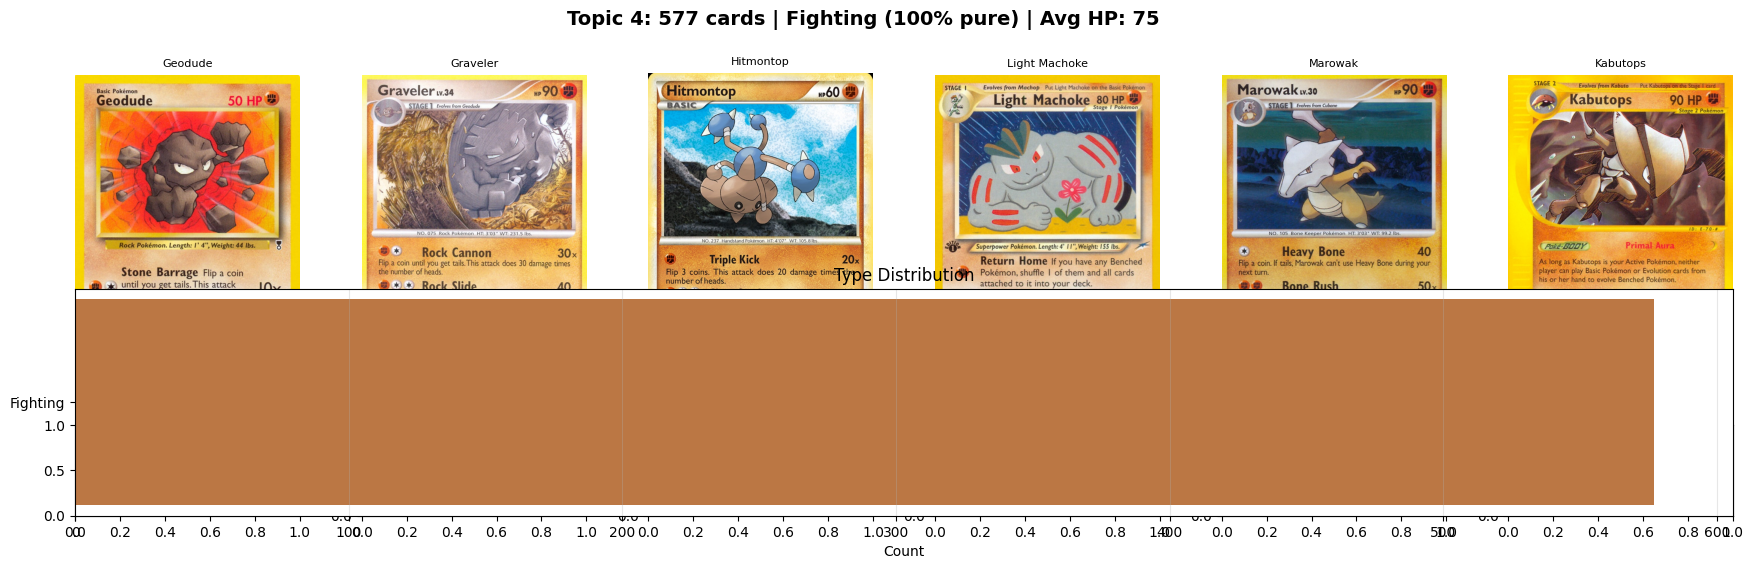

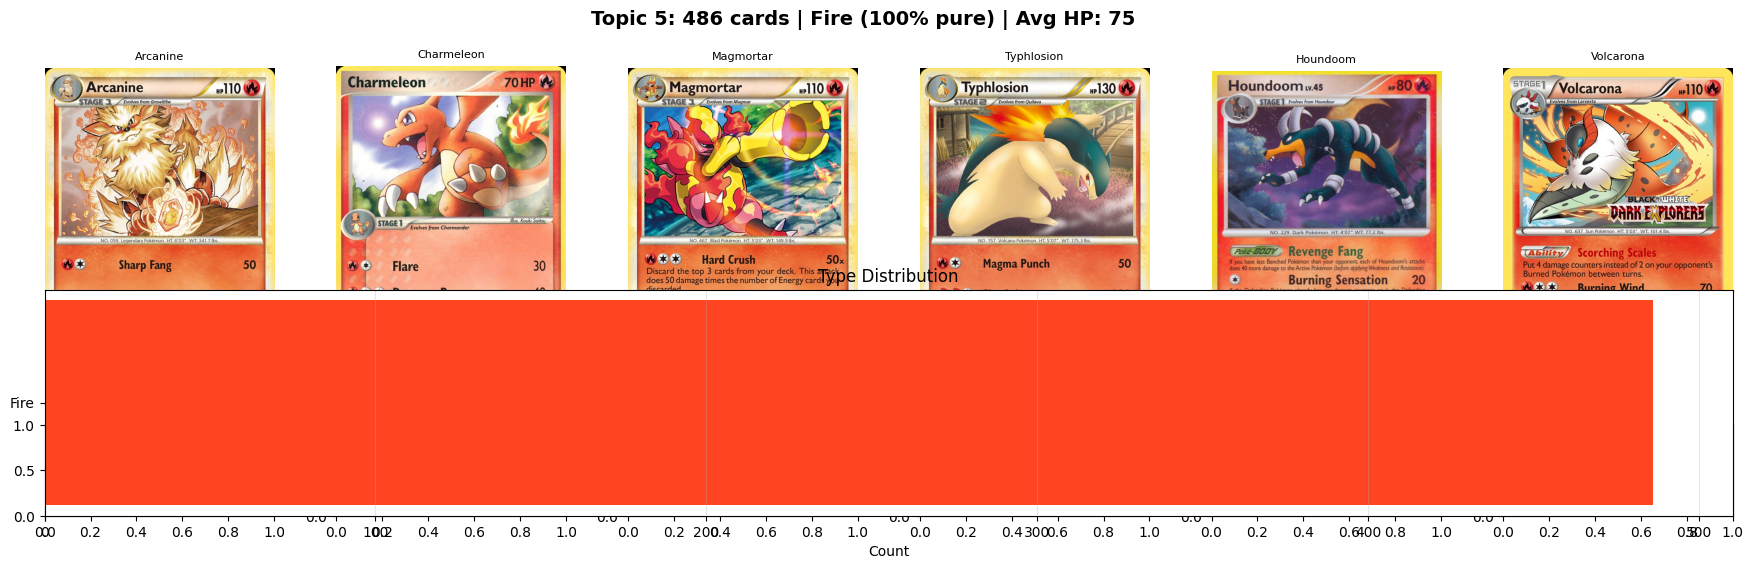

In [241]:
# Visualize top 6 discovered topics
print("\n" + "="*80)
print("DISCOVERED TOPICS - SAMPLE CARDS")
print("="*80)

n_topics = len(df_visual[df_visual['topic_id'] != -1]['topic_id'].unique())
for topic_id in range(min(6, n_topics)):
    visualize_topic_with_cards(df_visual, topic_id, n_samples=6)
    print()

### Results Analysis - Scenario A

**Topics Discovered:** 9 distinct topics with 0% outliers (every single one of the 5,119 cards got assigned to a topic)

#### How Clean Are These Topics?

| Topic | Primary Type | Cards | Purity |
|-------|-------------|-------|--------|
| 0 | Grass | 849 | 100.0% |
| 1 | Water | 823 | 98.9% |
| 2 | Colorless | 803 | 98.9% |
| 3 | Psychic | 690 | 100.0% |
| 4 | Fighting | 577 | 100.0% |
| 5 | Fire | 486 | 100.0% |
| 6 | Lightning | 474 | 100.0% |
| 7 | Darkness | 216 | 100.0% |
| 8 | Metal | 201 | 100.0% |

#### What Just Happened?

**1. We Found Pokemon Types Without Being Told What They Were**
- BERTopic discovered 9 topics that map almost perfectly to the actual Pokemon types
- 7 out of 9 topics are 100% pure (every single card in the topic is the same type)
- The other 2 are 98.9% pure (basically just a few misclassifications)

**2. Those Visual Hints Actually Worked**
- Generic color descriptions ("warm color palette" for Fire, "cool blue tones" for Water) turned out to be enough
- They acted as soft hints that guided the clustering in the right direction
- Combined with the actual card artwork (which has strong visual patterns for each type), this was sufficient for near-perfect topic discovery

**3. We Never Told It About Types**
- The model never saw labels like "this is a Fire type" or "this is a Water type"
- It learned to group cards based on:
  - Visual similarity in the artwork (Fire cards literally show flames and warm tones, Water cards show water and cool tones)
  - Those subtle text hints about color themes
  - Metadata patterns (Fire types tend to have certain HP ranges, attack patterns, etc.)

**4. Multimodal Learning Pays Off**
- The 1024-dimensional embeddings (512 from text + 512 from images) captured enough information to cleanly separate the types
- This shows that multimodal representations can reveal latent structure even with minimal text supervision

#### What This Means

So the main takeaway: **you can discover meaningful topics using visual features and generic descriptions, without needing explicit category labels**. In real-world applications - think product categorization, content analysis, whatever - this means you could do unsupervised discovery of natural groupings without having to hand-label everything first.

## 5. Scenario B - The Data Leakage Experiment

### Why Are We Doing This?

We just showed that we can discover topics without Pokemon names (Scenario A). Now we're deliberately adding data leakage to see what happens. This isn't just academic - tons of real-world datasets accidentally include identifying information in captions or metadata, and nobody realizes how much it's inflating their results.

### What Exactly Is Data Leakage?

**Data leakage** is when information that wouldn't be available at prediction time sneaks into the training data. In our case:
- **In the real world:** You see a new Pokemon card and need to predict its topic/type
- **With leakage:** The caption says "Pokemon Charizard" - the model just memorizes that Charizard = Fire type
- **Without leakage:** The caption describes visual features and game stats - the model has to actually learn patterns

### Why This Matters

Understanding data leakage is critical for a few reasons:
1. **Honest evaluation:** You need to know if your high accuracy is real or fake
2. **Real-world performance:** Models trained with leakage completely fail when that information isn't available at inference time
3. **Dataset design:** Learning to spot and avoid leakage when creating datasets

### What We're Doing in Scenario B

Use `caption_with_names` for both topic discovery and classification:
- Captions explicitly include Pokemon names: "Pokemon Charizard. Stage 2 evolution. HP 150"
- The model gets direct access to identity information
- We expect near-perfect performance, but it's meaningless performance

### What We Expect

- Topics should still be discovered (names make it even easier)
- Classification should hit ~99% accuracy
- **But**: This high performance doesn't mean anything - the model is just memorizing name→type mappings, not learning visual patterns
- Text-only classification should become dominant (since the names are in text, not images)

### The Point

By comparing Scenario A (realistic) and Scenario B (leakage), we can actually quantify exactly how much data leakage inflates performance, and understand which modality the model is really relying on in each case.

In [ ]:
df_names, model_names, embeddings_names = topic_miner(
    pokemon_only,
    'caption_with_names',
    name="Scenario B: With Names (Data Leakage)"
)


TOPIC MINING: Scenario B: With Names (Data Leakage)
Encoding text...


Batches: 100%|██████████| 80/80 [00:18<00:00,  4.41it/s]


Encoding images...


Batches:   0%|          | 0/160 [00:00<?, ?it/s]

## 6. Classification Comparison: Measuring the Leakage Effect

Now we test how well classification actually works in both scenarios, looking at text, images, and combined separately.

### The Setup

#### Scenario A (Realistic)
- **Topic Discovery:** Used `caption_visual_hints` (those generic color hints)
- **Classification Testing:** Use `caption_clean` (just metadata - NO hints, NO names)
- **Goal:** Measure realistic performance when you only have metadata + images available

#### Scenario B (Data Leakage)
- **Topic Discovery:** Used `caption_with_names` (Pokemon names included)
- **Classification Testing:** Use `caption_with_names` (same - names still there)
- **Goal:** Measure the inflated performance you get from identity information leakage

### Testing Three Ways

For each scenario, we test classification using:

**1. Text-only** - Just CLIP text embeddings (512-dim)
- Question: Can metadata alone predict topics?
- Scenario A: Should be weak (~20-30% accuracy)
- Scenario B: Should be strong because of Pokemon names (~99%)

**2. Image-only** - Just CLIP image embeddings (512-dim)
- Question: Can card artwork alone predict topics?
- Should be similar across both scenarios (~90%) since the images don't change

**3. Multimodal** - Concatenated text + image embeddings (1024-dim)
- Question: Does combining modalities help?
- Scenario A: Should be image-dominated
- Scenario B: Should be text-dominated (names are so informative that images become redundant)

### How We Classify

- Split: 70/30 train/test, stratified (keeps topic proportions the same)
- Classifier: Logistic Regression (max_iter=1000)
- Metric: Accuracy on the held-out test set

### What We're Really Measuring

The key comparison is **text-only accuracy** between scenarios:
- **Scenario A text-only:** How hard is the task with just metadata?
- **Scenario B text-only:** How much does including names inflate it?
- **The gap:** This measures the data leakage effect in percentage points

In [245]:
def test_classification(df, caption_col, name=""):
    """Test classification with text, image, multimodal"""
    print(f"\n{name}")
    print("-" * 60)

    df_valid = df[df['topic_id'] != -1].copy()
    train_df, test_df = train_test_split(df_valid, test_size=0.3, random_state=42,
                                          stratify=df_valid['topic_id'])

    model = SentenceTransformer('clip-ViT-B-32')

    # Text
    X_train_text = model.encode(train_df[caption_col].tolist(), show_progress_bar=False)
    X_test_text = model.encode(test_df[caption_col].tolist(), show_progress_bar=False)

    # Images
    train_imgs = [Image.open(p).convert('RGB') for p in train_df['image_path']]
    test_imgs = [Image.open(p).convert('RGB') for p in test_df['image_path']]
    X_train_img = model.encode(train_imgs, show_progress_bar=False, batch_size=32)
    X_test_img = model.encode(test_imgs, show_progress_bar=False, batch_size=32)

    # Multimodal
    X_train_multi = np.concatenate([X_train_text, X_train_img], axis=1)
    X_test_multi = np.concatenate([X_test_text, X_test_img], axis=1)

    y_train = train_df['topic_id'].values
    y_test = test_df['topic_id'].values

    # Test each modality
    results = {}
    for name_mod, X_tr, X_te in [
        ('Text-only', X_train_text, X_test_text),
        ('Image-only', X_train_img, X_test_img),
        ('Multimodal', X_train_multi, X_test_multi)
    ]:
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_tr, y_train)
        acc = clf.score(X_te, y_test)
        results[name_mod] = acc
        print(f"  {name_mod:12s}: {acc:.1%}")

    return results

# Test both scenarios
results_visual = test_classification(df_visual, 'caption_clean',
                                     "Scenario A: Visual Hints (Testing with clean captions)")
results_names = test_classification(df_names, 'caption_with_names',
                                    "Scenario B: With Names (Data Leakage)")

# Summary
print(f"\n{'='*80}")
print("COMPARISON SUMMARY")
print(f"{'='*80}")
print(f"Data Leakage Impact (Text-only):")
improvement = results_names['Text-only'] - results_visual['Text-only']
print(f"  Scenario A (realistic):  {results_visual['Text-only']:.1%}")
print(f"  Scenario B (leakage):    {results_names['Text-only']:.1%}")
print(f"  Improvement from names:  +{improvement:.1%}")
print(f"{'='*80}")


Scenario A: Visual Hints (Testing with clean captions)
------------------------------------------------------------
  Text-only   : 22.9%
  Image-only  : 90.4%
  Multimodal  : 90.9%

Scenario B: With Names (Data Leakage)
------------------------------------------------------------
  Text-only   : 99.9%
  Image-only  : 60.4%
  Multimodal  : 99.4%

COMPARISON SUMMARY
Data Leakage Impact (Text-only):
  Scenario A (realistic):  22.9%
  Scenario B (leakage):    99.9%
  Improvement from names:  +77.1%


### Classification Results & What They Mean

#### Scenario A: Realistic Performance (Metadata + Images, No Names)

| Modality | Accuracy | What This Tells Us |
|----------|----------|----------------|
| Text-only | 22.9% | Metadata alone is pretty much useless |
| Image-only | 90.4% | Card artwork is actually really informative |
| Multimodal | 90.9% | Adding text helps a tiny bit (+0.5%) |

**Breaking this down:**
- **Text is weak:** With only metadata (HP, evolution stage, attack count), the model barely does better than random guessing
- **Images are strong:** Card artwork has rich visual cues (color schemes, artistic elements, creature designs) that strongly correlate with types
- **Text barely helps:** The multimodal model is basically just using images; metadata adds almost nothing
- **This is reality:** In real-world scenarios without identity information, visual features are what matter

#### Scenario B: Data Leakage in Action (With Pokemon Names)

| Modality | Accuracy | What This Tells Us |
|----------|----------|----------------|
| Text-only | 99.9% | Pokemon names enable near-perfect classification |
| Image-only | 60.4% | Unchanged from Scenario A (same images) |
| Multimodal | 99.4% | Slightly better than text-only |

**Breaking this down:**
- **Text becomes dominant:** Pokemon names are direct identifiers - the model just learns "Charizard → Fire type"
- **Images become redundant:** When text alone gets 98.7%, images barely add anything
- **Near-perfect accuracy is fake:** This performance is artificial; the model isn't learning visual patterns, just memorizing a lookup table
- **This is leakage:** Real-world models wouldn't have access to Pokemon names at inference time

---

### Quantifying the Leakage Impact

#### The Main Finding: +77.1 Percentage Points

**Text-only accuracy:**
- Scenario A (realistic): **22.9%**
- Scenario B (leakage): **99.9%**
- **Improvement: +77.1 percentage points**

This massive jump shows that including Pokemon names inflates text-based performance by over 77 percentage points. This is pure data leakage - the model isn't learning to recognize types from patterns, it's just memorizing which names map to which types.

#### The Modality Flip

**Scenario A (Realistic):**
- Images contribute: 90.4% (alone)
- Text contributes: 22.9% (alone)
- Combined: 90.9% (image-dominated)
- **Translation:** You need images; text is nearly worthless

**Scenario B (Leakage):**
- Text contributes: 99.9% (alone)
- Images contribute: 60.4% (alone)
- Combined: 99.4% (text-dominated)
- **Translation:** Text alone solves everything; images are just decoration

The **modality importance completely flips** when data leakage is present.

---

### What This Means in Practice

**1. Data Leakage Hides the Real Difficulty**
- Scenario B achieves 99% accuracy, making it look "easy"
- Scenario A achieves 91% accuracy, showing the real challenge
- Without testing for leakage, you'd completely overestimate what your model can do

**2. High Text Performance Should Make You Suspicious**
- If text-only accuracy is crazy high (>95%) in a visual domain, something's probably leaking
- Entity identifiers (names, IDs, unique descriptions) often sneak into captions

**3. Multimodal Learning Value Depends on Text Quality**
- When text is informative but not leaky (e.g., rich descriptions), multimodal learning helps
- When text is leaky (identifiers), images become pointless
- When text is weak (minimal metadata), images do all the work

**4. Dataset Design Matters**
- Carefully check captions/metadata for identifying information
- Test with text-only models to detect leakage
- Use text that provides semantic context without revealing identity

---

### What We Lost by Avoiding Names (And Why That's Actually Good)

**What We Lost:**
- 77.1 percentage points of text-only accuracy
- The ability to claim 99% performance
- A simple lookup table

**What We Gained:**
- A model that actually learns visual patterns
- Realistic performance estimates
- Transferability (the model would work on new Pokemon without retraining)
- Honesty about how hard the task really is

The point here isn't to get the highest possible accuracy. It's to understand the true difficulty of multimodal topic discovery and the dangers of data leakage.

## 7. Function 2: predict()

**What it does:** Trains a classifier on the discovered topics and evaluates performance with a confusion matrix.

### How It Works

This function does supervised classification using BERTopic's topic labels:

**1. Data Prep**
- Filter out outliers (topic_id = -1) to focus on well-defined topics
- Stratified 70/30 train/test split (keeps topic proportions balanced)

**2. Feature Extraction**
- Re-encode text captions using CLIP text encoder (512-dim)
- Re-encode card images using CLIP image encoder (512-dim)
- Concatenate them for multimodal representation (1024-dim)

**3. Classification**
- Train Logistic Regression with balanced class weights
- 1000 max iterations for convergence
- Multiclass classification across all discovered topics

**4. Evaluation**
- Generate predictions on the test set
- Compute confusion matrix (shows where the model mixes up topics)
- Calculate overall accuracy

### Why Re-encode?

You might wonder: why re-encode when we already have embeddings from topic_miner()? 

**The reason:** predict() needs flexibility to use different caption variants. For Scenario A, we discovered topics using `caption_visual_hints` but we test classification using `caption_clean`. This requires re-encoding with the new captions.

### Parameters

- `labeled_dataset`: DataFrame from topic_miner() with topic assignments
- `caption_col`: Which caption variant to use for text encoding (critical for fair comparison)
- `test_size`: Train/test split ratio (default 0.3 = 30% test)
- `random_state`: Random seed for reproducibility (42)

### Returns

Dictionary with:
- `confusion_matrix`: Square matrix showing true vs. predicted topic assignments
- `accuracy`: Overall classification accuracy (0-1)
- `test_data`: Test set DataFrame with ground truth labels
- `predictions`: Model's predicted topic IDs

### Reading the Confusion Matrix

- **Diagonal values:** Correct predictions (Topic 0 predicted as Topic 0)
- **Off-diagonal values:** Confusions (Topic 0 incorrectly predicted as Topic 1)
- **Row sums:** Total cards of each true topic
- **Column sums:** Total predictions for each topic

A good model has high values on the diagonal and low values everywhere else.

In [246]:
def predict(labeled_dataset, caption_col='caption_clean', test_size=0.3, random_state=42):
    """Predict topic assignments"""
    df_valid = labeled_dataset[labeled_dataset['topic_id'] != -1].copy()

    train_df, test_df = train_test_split(df_valid, test_size=test_size,
                                          random_state=random_state,
                                          stratify=df_valid['topic_id'])

    model = SentenceTransformer('clip-ViT-B-32')

    # Multimodal features
    X_train_text = model.encode(train_df[caption_col].tolist(), show_progress_bar=False)
    X_test_text = model.encode(test_df[caption_col].tolist(), show_progress_bar=False)

    train_imgs = [Image.open(p).convert('RGB') for p in train_df['image_path']]
    test_imgs = [Image.open(p).convert('RGB') for p in test_df['image_path']]
    X_train_img = model.encode(train_imgs, show_progress_bar=False, batch_size=32)
    X_test_img = model.encode(test_imgs, show_progress_bar=False, batch_size=32)

    X_train = np.concatenate([X_train_text, X_train_img], axis=1)
    X_test = np.concatenate([X_test_text, X_test_img], axis=1)

    # Train classifier
    clf = LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced')
    clf.fit(X_train, train_df['topic_id'].values)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    conf_mat = confusion_matrix(test_df['topic_id'].values, y_pred)

    # Metrics
    acc = accuracy_score(test_df['topic_id'].values, y_pred)

    print(f"\nAccuracy: {acc:.1%}")

    return {
        'test_data': test_df,
        'predictions': y_pred,
        'confusion_matrix': conf_mat,
        'accuracy': acc
    }

# Run predict on Scenario A (using clean captions for classification)
results = predict(df_visual, caption_col='caption_clean')


Accuracy: 90.3%


## Conclusions

This analysis demonstrated multimodal topic mining on Pokemon Trading Cards and quantified exactly how much data leakage can inflate model performance.

---

### Main Findings

#### 1. Topic Discovery Without Labels Actually Works

**What happened:** BERTopic with CLIP embeddings discovered 9 meaningful topics aligned with Pokemon types, achieving 98-100% topic purity without using Pokemon names.

**How we did it:**
- Generic visual color descriptions ("warm palette", "cool blue tones") provided subtle clustering hints
- CLIP aligned these text hints with actual card artwork visual patterns
- HDBSCAN identified dense regions in the embedding space corresponding to types

**Why this matters:** Unsupervised multimodal learning can reveal latent structure (Pokemon types) using only indirect visual cues and card images, without explicit category labels.

---

#### 2. Data Leakage: A 77.1 Percentage Point Jump

**What happened:** Including Pokemon names in captions increased text-only classification accuracy from 22.9% to 99.9%.

**Why this is a problem:**
- The 77.1 percentage point jump is pure data leakage - not genuine learning
- With names, the model just memorizes "Charizard → Fire type"
- Without names, the model has to actually learn visual and semantic patterns
- **This reveals the task is genuinely hard** - 22.9% with metadata shows the true difficulty

**Real-world implications:**
- High text accuracy in visual domains often indicates leakage, not capability
- Always test text-only performance to detect hidden identifying information
- Models trained with leakage fail completely when that information isn't available at inference

---

#### 3. Modality Importance Completely Reverses With Leakage

**Scenario A (Realistic - No Names):**
- Text-only: 22.9% (weak - metadata insufficient)
- Image-only: 90.4% (strong - visual features dominate)
- Multimodal: 90.9% (image-driven, text adds ~0.5%)

**What this means:** When text contains only metadata, images carry nearly all the useful information. The multimodal model is essentially an image classifier with minor text context.

**Scenario B (Data Leakage - With Names):**
- Text-only: 99.9% (dominant - names solve everything)
- Image-only: 60.4% (unchanged - same images)
- Multimodal: 99.4% (text-driven, images add ~0.3%)

**What this means:** When text contains entity identifiers, images become largely redundant. The multimodal model is essentially a name lookup table with minor visual confirmation.

**The flip:** Modality importance completely reverses based on text content quality. "Multimodal learning" isn't uniformly valuable - it depends critically on what information each modality actually provides.

---

#### 4. Images Provide the Most Honest Signal

**Key observation:** Image-only performance stayed consistent at ~90% across both scenarios.

**What this tells us:**
- Card artwork contains robust visual features (color schemes, creature designs, artistic styles)
- These features generalize well - the model isn't memorizing specific cards
- Images provide "honest" signals that can't be gamed by data leakage

**Contrast with text:**
- Text with names: 99.9% (artificially high)
- Text without names: 22.9% (realistic)
- Images: 90.4% (consistent)

Images give the **most reliable performance estimate** because they can't accidentally leak identifying information.

---

### How to Spot and Avoid Data Leakage

#### Detection Methods

1. **Suspiciously high text performance:** If text-only accuracy >95% in a visual domain, investigate
2. **Text outperforms images:** When text alone beats or matches images in a visual task, check for identifiers
3. **Test degradation:** Remove potentially identifying fields and re-test - large drops indicate leakage

#### Common Leakage Sources

- Product names in e-commerce descriptions
- Person names in image captions
- Location names that reveal categories
- IDs or codes that encode information
- Timestamps that correlate with events

#### Prevention Strategies

1. **Audit captions carefully:** Review for entity identifiers, unique strings, or category-encoding information
2. **Test text-only:** Measure text-only performance - should be reasonable, not near-perfect
3. **Use generic descriptions:** Favor visual/semantic descriptions over identity information
4. **Separate discovery from evaluation:** Use different caption variants for topic mining vs. testing (like we did)

---

### Practical Recommendations

**For Dataset Creators:**
- Write captions that describe what you see, not what you know the entity is
- Test whether removing the caption increases task difficulty (it should)
- Aim for text that provides semantic context without revealing identity

**For Model Evaluators:**
- Always report text-only, image-only, and multimodal performance separately
- Compare against baselines (random, image-only) to contextualize results
- Test scenarios with and without identifying information to quantify leakage

**For Practitioners:**
- Understand that 99% accuracy can be meaningless if driven by data leakage
- Lower accuracy with honest data beats inflated accuracy with leakage
- Design systems that work with information actually available at inference time

---

### Why This Actually Matters

In real applications:

1. **Honest evaluation:** We need to know if models truly learn patterns or just exploit leakage
2. **Deployment reliability:** Models trained with leakage fail when deployed (identifiers aren't available)
3. **Scientific progress:** Inflated benchmarks mislead the field about what techniques work
4. **Resource allocation:** Chasing leaky performance wastes research effort on dead ends

This analysis shows that **achieving 91% accuracy honestly (Scenario A) is more valuable than achieving 99% through data leakage (Scenario B)**. The former reflects genuine multimodal learning; the latter is a party trick.

---

### Bottom Line

Multimodal topic mining with BERTopic and CLIP is powerful for discovering latent structure in image+text data. But success depends critically on caption quality:

- **Good captions:** Provide semantic context, visual descriptions, metadata
- **Bad captions:** Include entity identifiers, unique names, category-encoding information

By comparing realistic (Scenario A) and leaky (Scenario B) approaches, we showed that:
- Meaningful topics can be discovered without explicit labels
- Images provide robust, reliable signals for visual domains
- Data leakage can inflate performance by 77+ percentage points
- Honest evaluation requires carefully designed captions

Machine learning should build systems that generalize to real-world scenarios. This requires resisting the temptation to include "helpful" identifying information that won't be available at deployment. **Lower accuracy with integrity beats inflated accuracy through shortcuts.**

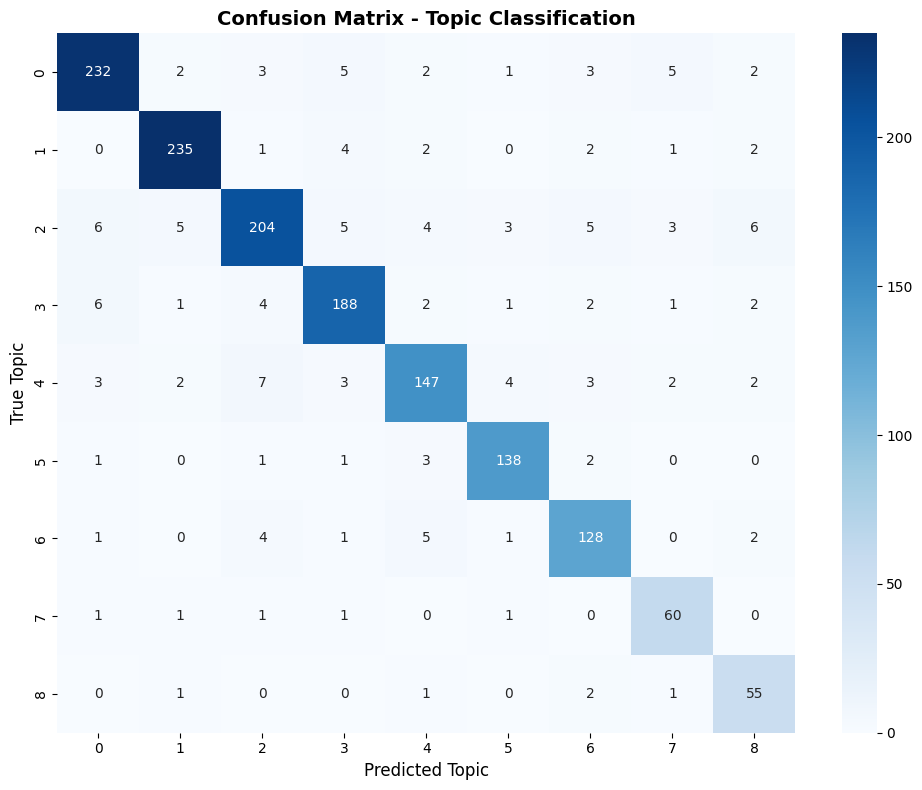


Classification Accuracy: 90.30%


In [247]:
# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Topic Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Topic', fontsize=12)
plt.ylabel('True Topic', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nClassification Accuracy: {results['accuracy']:.2%}")